# E4 · Floating-rate financing

**Optional decision:** Does a fixed-pay, receive-floating swap stabilize this project's interest bill? Read F4 and M2 first; allow 10–15 minutes. Assume an existing USD 1,000,000 loan, twelve interest-only months, and a single principal repayment at month 12. This explicitly differs from F1's fully amortizing fixed-rate loan; we are not resizing debt here.

All terms are hypothetical. Reference rates reset at each month's start, are known for that period, and equal 4% for months 1–6 then 6% for months 7–12. The lender adds a 3% spread. These are simple nominal annual rates with accrual fraction 1/12, paid at month-end. Baseline reference floor is zero.

The swap has USD 1,000,000 notional, pays fixed 5%, and receives the same reference on identical accrual periods and payment dates. No principal exchanges or collateral are included in the swap.

In [1]:
# Install the teaching package from GitHub when running in Google Colab.
# Local Jupyter uses the repository's existing environment.
import subprocess
import sys

if "google.colab" in sys.modules:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--quiet",
            "liquid-compute[colab] @ git+https://github.com/zach189/education.git@main",
        ]
    )
    from google.colab import output

    output.enable_custom_widget_manager()

In [2]:
from IPython.display import display

from liquid_compute.education import (
    explore_finance_series,
    plot_finance_series,
    show_finance_table,
)
from liquid_compute.floating_rates import (
    fixed_pay_swap_settlements_usd,
    floating_loan_interest_usd,
)

principal = 1_000_000
reference_rates = (0.04,) * 6 + (0.06,) * 6
spread = 0.03
fixed_rate = 0.05
periods = dict(year_fractions=(1 / 12,) * 12, payment_months=tuple(range(1, 13)))
print("Rates reset at period start; interest and swap cash settle at month-end.")

Rates reset at period start; interest and swap cash settle at month-end.


## Work one low-rate and one high-rate month

Loan interest is principal × (reference + spread) × year fraction. Signed swap outflow is notional × (fixed−reference) × year fraction. Positive swap amounts are payments; negative amounts are receipts.

At reference 4%, loan interest is USD 5,833.33 and swap outflow USD 833.33. At reference 6%, interest is USD 7,500 and swap outflow −USD 833.33. Both produce USD 6,666.67 combined charges before principal. Calculations retain full precision rather than rounding each monthly amount before aggregation.

In [3]:
direct_rows = []
for ref in (0.04, 0.06):
    interest = principal * (ref + spread) / 12
    swap_outflow = principal * (fixed_rate - ref) / 12
    direct_rows.append([ref, interest, swap_outflow, interest + swap_outflow])
show_finance_table(
    [
        "Annual reference fraction",
        "Loan interest USD",
        "Swap outflow USD",
        "Combined charge USD",
    ],
    direct_rows,
)
direct_year_interest = principal * ((0.04 + spread) * 0.5 + (0.06 + spread) * 0.5)
print(f"Direct year interest: USD {direct_year_interest:,.2f}")

| Annual reference fraction | Loan interest USD | Swap outflow USD | Combined charge USD |
| --- | --- | --- | --- |
| 0.04 | 5,833.33 | 833.33 | 6,666.67 |
| 0.06 | 7,500.00 | -833.33 | 6,666.67 |

Direct year interest: USD 80,000.00


## Preserve the dates and principal repayment

Total baseline interest is USD 80,000. Swap payments in the first half offset receipts in the second half, so net swap outflow over the year is zero. The combined charge is still USD 80,000.

The reusable rate adapter applies M2's signed difference arithmetic with explicit rate and accrual units, then reports payer outflow. It does not call a rate swap a commodity forward. The separate principal column repays USD 1,000,000 exactly once at month 12. Loan proceeds occurred before this example's opening balance; they are not fresh revenue.

In [4]:
loan = floating_loan_interest_usd(
    opening_principal_usd=(principal,) * 12,
    reference_rates=reference_rates,
    spread=spread,
    **periods,
)
swap = fixed_pay_swap_settlements_usd(
    notional_usd=(principal,) * 12,
    reference_rates=reference_rates,
    fixed_rate=fixed_rate,
    **periods,
)
principal_repayments = (0,) * 11 + (principal,)
show_finance_table(
    [
        "Month",
        "Reference fraction",
        "Interest USD",
        "Swap outflow USD",
        "Combined charge USD",
        "Principal USD",
        "Total outflow USD",
    ],
    [
        [
            a.payment_month,
            ref,
            a.outflow_usd,
            b.outflow_usd,
            a.outflow_usd + b.outflow_usd,
            repayment,
            a.outflow_usd + b.outflow_usd + repayment,
        ]
        for a, b, ref, repayment in zip(
            loan, swap, reference_rates, principal_repayments
        )
    ],
)
base_combined = sum(a.outflow_usd + b.outflow_usd for a, b in zip(loan, swap))

| Month | Reference fraction | Interest USD | Swap outflow USD | Combined charge USD | Principal USD | Total outflow USD |
| --- | --- | --- | --- | --- | --- | --- |
| 1.00 | 0.04 | 5,833.33 | 833.33 | 6,666.67 | 0.00 | 6,666.67 |
| 2.00 | 0.04 | 5,833.33 | 833.33 | 6,666.67 | 0.00 | 6,666.67 |
| 3.00 | 0.04 | 5,833.33 | 833.33 | 6,666.67 | 0.00 | 6,666.67 |
| 4.00 | 0.04 | 5,833.33 | 833.33 | 6,666.67 | 0.00 | 6,666.67 |
| 5.00 | 0.04 | 5,833.33 | 833.33 | 6,666.67 | 0.00 | 6,666.67 |
| 6.00 | 0.04 | 5,833.33 | 833.33 | 6,666.67 | 0.00 | 6,666.67 |
| 7.00 | 0.06 | 7,500.00 | -833.33 | 6,666.67 | 0.00 | 6,666.67 |
| 8.00 | 0.06 | 7,500.00 | -833.33 | 6,666.67 | 0.00 | 6,666.67 |
| 9.00 | 0.06 | 7,500.00 | -833.33 | 6,666.67 | 0.00 | 6,666.67 |
| 10.00 | 0.06 | 7,500.00 | -833.33 | 6,666.67 | 0.00 | 6,666.67 |
| 11.00 | 0.06 | 7,500.00 | -833.33 | 6,666.67 | 0.00 | 6,666.67 |
| 12.00 | 0.06 | 7,500.00 | -833.33 | 6,666.67 | 1,000,000.00 | 1,006,666.67 |

## Explore the matched reference component

For full matching, reference cancels algebraically: P(reference+spread) + P(fixed−reference) = P(fixed+spread). Thus annual combined charges remain 8% of principal in this example. The loan spread remains payable; it is not hedged away.

The chart compares flat reference scenarios, not a time path. Controls vary the assumed fixed swap rate and fraction of principal covered. They are independent of the worked experiments. Changing the fixed rate is a hypothetical contract comparison, not a claim that a counterparty would offer that rate at no cost.

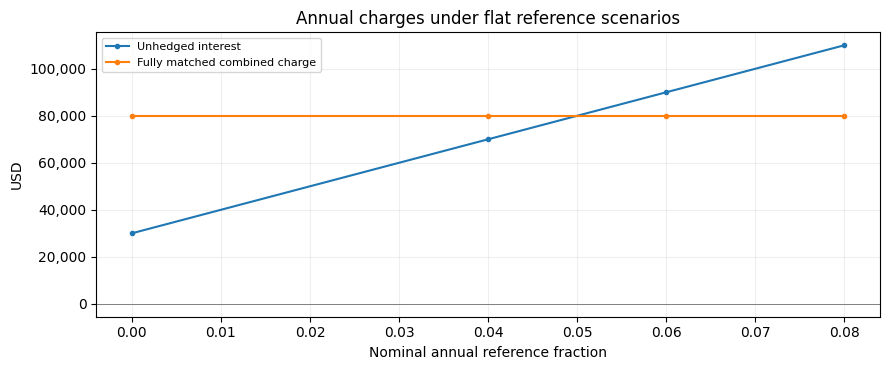

In [5]:
def financing_scenario(
    refs,
    notional=principal,
    floor=0.0,
    fixed=fixed_rate,
    balance=principal,
    margin=spread,
    dates=periods.copy(),
):
    from liquid_compute.floating_rates import (
        fixed_pay_swap_settlements_usd,
        floating_loan_interest_usd,
    )

    loan_rows = floating_loan_interest_usd(
        opening_principal_usd=(balance,) * 12,
        reference_rates=refs,
        spread=margin,
        reference_floor=floor,
        **dates,
    )
    swap_rows = fixed_pay_swap_settlements_usd(
        notional_usd=(notional,) * 12, reference_rates=refs, fixed_rate=fixed, **dates
    )
    interest = sum(r.outflow_usd for r in loan_rows)
    hedge = sum(r.outflow_usd for r in swap_rows)
    return interest, hedge, interest + hedge


reference_grid = (0.0, 0.04, 0.06, 0.08)
flat_cases = [financing_scenario((ref,) * 12) for ref in reference_grid]
display(
    plot_finance_series(
        {
            "Unhedged interest": [r[0] for r in flat_cases],
            "Fully matched combined charge": [r[2] for r in flat_cases],
        },
        title="Annual charges under flat reference scenarios",
        xlabel="Nominal annual reference fraction",
        x_values=reference_grid,
    )
)


def rate_explorer(
    values, grid=reference_grid, balance=principal, margin=spread, dates=periods.copy()
):
    from liquid_compute.floating_rates import (
        fixed_pay_swap_settlements_usd,
        floating_loan_interest_usd,
    )

    fraction = values["Hedge fraction"]
    if not 0 <= fraction <= 1:
        raise ValueError("Hedge fraction must be between 0 and 1")
    combined = []
    for ref in grid:
        loan_rows = floating_loan_interest_usd(
            opening_principal_usd=(balance,) * 12,
            reference_rates=(ref,) * 12,
            spread=margin,
            **dates,
        )
        hedge_rows = fixed_pay_swap_settlements_usd(
            notional_usd=(balance * fraction,) * 12,
            reference_rates=(ref,) * 12,
            fixed_rate=values["Fixed annual rate"],
            **dates,
        )
        combined.append(
            sum(a.outflow_usd + b.outflow_usd for a, b in zip(loan_rows, hedge_rows))
        )
    return {"Combined annual charges": combined}


explore_finance_series(
    {"Fixed annual rate": 0.05, "Hedge fraction": 1.0},
    rate_explorer,
    title="Reference coverage",
    xlabel="Nominal annual reference fraction",
    x_values=reference_grid,
);

## Experiment 1 · Raise reference to 8%

Replace the entire reference path with 8%, holding spread, swap fixed rate, balance and dates unchanged. Loan interest rises to USD 110,000, but the full swap receives USD 30,000, retaining USD 80,000 combined charges.

The offset requires the same reference definition, observation convention, notional, accrual factor and settlement dates. A shared label such as “floating” is insufficient to establish that match. M3's benchmark-alignment lesson applies here even though the underlying unit is an interest rate.

In [6]:
high_reference = financing_scenario((0.08,) * 12)
show_finance_table(
    ["Case", "Loan interest USD", "Swap outflow USD", "Combined charge USD"],
    [
        [
            "Baseline 4% then 6%",
            sum(r.outflow_usd for r in loan),
            sum(r.outflow_usd for r in swap),
            base_combined,
        ],
        ["Flat 8%", *high_reference],
    ],
)

| Case | Loan interest USD | Swap outflow USD | Combined charge USD |
| --- | --- | --- | --- |
| Baseline 4% then 6% | 80,000.00 | 0.00 | 80,000.00 |
| Flat 8% | 110,000.00 | -30,000.00 | 80,000.00 |

The negative USD 30,000 swap outflow is cash received. It offsets increased interest rather than repaying any principal. The USD 1,000,000 maturity obligation still exists.

## Experiment 2 · Hedge only half the principal

Restore the same high-reference stress but use USD 500,000 swap notional. Half the reference exposure now remains. Zero hedge is also shown as a boundary: it produces exactly the unhedged interest bill. There is no automatic adjustment of swap notional to the loan balance; matching must be specified.

In [7]:
half_hedge = financing_scenario((0.08,) * 12, notional=500_000)
no_hedge = financing_scenario((0.08,) * 12, notional=0)
show_finance_table(
    ["Notional USD", "Loan interest USD", "Swap outflow USD", "Combined charge USD"],
    [[1_000_000, *high_reference], [500_000, *half_hedge], [0, *no_hedge]],
)

| Notional USD | Loan interest USD | Swap outflow USD | Combined charge USD |
| --- | --- | --- | --- |
| 1,000,000.00 | 110,000.00 | -30,000.00 | 80,000.00 |
| 500,000.00 | 110,000.00 | -15,000.00 | 95,000.00 |
| 0.00 | 110,000.00 | 0.00 | 110,000.00 |

Half coverage receives USD 15,000 and leaves USD 95,000 combined charges. With no hedge, charges remain USD 110,000. A partial swap reduces sensitivity without fixing the entire bill.

## Experiment 3 · A floor in only the loan

Use a flat 4% reference, but impose a 5% loan reference floor before adding the 3% spread. The swap still receives actual 4%. It therefore pays 1% net, while loan interest is already 8%. The floored borrowing term and unfloored swap reference do not cancel.

In [8]:
floor_case = financing_scenario((0.04,) * 12, floor=0.05)
matching_low = financing_scenario((0.04,) * 12)
show_finance_table(
    ["Loan floor", "Loan interest USD", "Swap outflow USD", "Combined charge USD"],
    [["Zero", *matching_low], ["5% reference floor", *floor_case]],
)

| Loan floor | Loan interest USD | Swap outflow USD | Combined charge USD |
| --- | --- | --- | --- |
| Zero | 70,000.00 | 10,000.00 | 80,000.00 |
| 5% reference floor | 80,000.00 | 10,000.00 | 90,000.00 |

The mismatched floor produces USD 90,000 combined charges: USD 80,000 loan interest plus USD 10,000 swap payment. The extra USD 10,000 is a real contractual residual, not a calculation error.

## Review the covered component

A matched fixed-pay swap stabilizes only its covered reference component. It does not remove lender spread, principal repayment, floor mismatch, basis or counterparty exposure. Compare the existing cases before describing financing as fixed-rate. For actual instruments, fixing, compounding, day-count and payment conventions must be checked separately.

In [9]:
show_finance_table(
    ["Previously calculated case", "Annual combined charges USD"],
    [
        ["Baseline matched", base_combined],
        ["8% reference fully matched", high_reference[2]],
        ["8% reference half matched", half_hedge[2]],
        ["4% reference with loan-only floor", floor_case[2]],
    ],
)

| Previously calculated case | Annual combined charges USD |
| --- | --- |
| Baseline matched | 80,000.00 |
| 8% reference fully matched | 80,000.00 |
| 8% reference half matched | 95,000.00 |
| 4% reference with loan-only floor | 90,000.00 |

**Next:** E5 optionally measures sample risk; return to M7 for hedge collateral and interim liquidity. The planned capstone can combine these dated payments with other transaction cash, but no capstone implementation is added here.

[The New York Fed](https://www.newyorkfed.org/markets/reference-rates/sofr) defines SOFR as a measure of overnight Treasury-secured borrowing cost. Our invented monthly reference path is not SOFR data or a SOFR compounding implementation. No live rates, collateral, fees, default losses or fair swap-strike valuation are included.